# Heisenberg Evolution and Operator Entanglement in a Spin Chain using MPO

(Matrix Product Operators) with bond dimension χ controlled by operator entanglement.



In [ ]:
# using Pkg; Pkg.add("ITensors"); Pkg.add("ITensorMPS")
using ITensors, ITensorMPS

---

## Spin chain

We will initialize a chain of $N$ particles $1/2$.

In [156]:
# nombre de spins
N = 6

# creation des sites
sites = ITensors.siteinds("S=1/2", N)

println(sites)

Index{Int64}[(dim=2|id=211|"S=1/2,Site,n=1"), (dim=2|id=252|"S=1/2,Site,n=2"), (dim=2|id=685|"S=1/2,Site,n=3"), (dim=2|id=527|"S=1/2,Site,n=4"), (dim=2|id=300|"S=1/2,Site,n=5"), (dim=2|id=511|"S=1/2,Site,n=6")]


---

## Construction of the Hamiltonian

Here we will take the Hamiltonian :

$$H = \sum_j ( X_j X_{j+1} + gX_j + hZ_j ) \quad \text{with} \quad g=1/2, h=1/2$$

In [157]:
g = 0.5
h = 0.5

function compute_H(g::Float64=0.5, h::Float64=0.5)::MPO
  ampo = AutoMPO()

  for j=1:N-1
      add!(ampo,"X",j,"X",j+1) # interaction XX
  end
  for j=1:N
      add!(ampo, g,"X",j) # champ X
      add!(ampo, h,"Z",j) # champ Z
  end

  return MPO(ampo, sites)
end

H = compute_H(g,h)

println("max bond dimension : ", maxlinkdim(H))

max bond dimension : 3


small max bond dimension, $3$.

The full matrix would be: $2^N \times 2^N$

so for $N=6$: $64 \times 64$

But the MPO remains very compact because information only needs to propagate locally within the MPO for this Hamiltonian.

---

## Temporal evolution

In the Heisenberg picture, the evolution applies to the operator.

We will therefore seek here to evolve our operator $\hat{O}$,
which is defined by:

$$\hat{O}(t) = U^{\dagger}\hat{O}U$$

Let us then calculate the evolution operator $U = e^{-iHt}$.

Calculating $U$ for $N$ that is too large is too computationally expensive, we will seek to simplify it by using:

### Trotter decomposition

$$H = \sum_j h_{j,j+1} \quad \text{where} \quad h_{j,j+1} = X_jX_{j+1} +\frac{g}{2}( X_j+X_{j+1})+\frac{h}{2}( Z_j+Z_{j+1})$$

$H$ can be decompose between $j_{odd}$ and $j_{even}$ so $H = H_{odd} + H_{even}$.

We take a small time step $\tau << 1$,
we can use the Baker-Campbell-Hausdorff formula to approximate :

$$U(\tau) = e^{-i \tau H} = e^{-i \tau (H_{odd} + H_{even})} = e^{-i \tau H_o} e^{-i \tau H_e} e^{-i \tau^2 [H_o,H_e]} = e^{-i \tau H_o} e^{-i \tau H_e} + O(\tau^2)$$
because of
$$e^{-i \tau^2 [H_o,H_e]} = \mathbb{I} - i \tau^2 [H_o, H_e] + O(\tau^4) $$

We have an error per time step $\tau$ of order $\tau^2$.

the $h_{j,j+1}$ for $j$ odd or even commute with each other, so

$$e^{-i \tau H_o} = e^{-i \tau \sum_{j_{odd}}h_{j,j+1}} = \prod_{j_{odd}} e^{-i \tau h_{j,j+1}} $$

same for $H_{even}$.

in conclusion we take

$$U^{TEBD2}(\tau) = e^{-iH\tau} \approx \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2} \prod_{j_{even}}e^{-i\tau h_{j,j+1}} \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2}$$

Wich have an error order of $\tau^3$.

Each term: $e^{-i\tau h_{j,j+1}}$ acts only on 2 spins.
Therefore, it can be represented as a 4-index tensor.
This is called a **TEBD gate**.

In [158]:
cutoff = 1e-8
τ = 0.1

# Hamiltonien local h_{j,j+1}
function build_two_site_hamiltonian(j::Int64)
  s1 = sites[j]
  s2 = sites[(j + 1)]
  hj =
     op("X", s1) * op("X", s2) +
     (g/2) * (op("X", s1) * op("Id", s2) + op("Id", s1) * op("X", s2)) +
     (h/2) * (op("Z", s1) * op("Id", s2) + op("Id", s1) * op("Z", s2))
  return hj
end

# Construction des gates TEBD
function build_gates(τ::Float64)::Tuple{Vector{ITensor}, Vector{ITensor}}
  gates_odd = ITensor[]
  gates_even = ITensor[]
  for j in 1:(N-1)
      hj = build_two_site_hamiltonian(j)
      if isodd(j)
        Gj = exp(-im * τ / 2 * hj) # gate Trotter ordre 2
        push!(gates_odd, Gj)
      else
        Gj = exp(-im * τ * hj) # gate Trotter ordre 2
        push!(gates_even, Gj)
      end
  end
  return gates_odd, gates_even
end

# Application U† O U pour une liste de gates
function apply_heisenberg_step(O::MPO, gates::Vector{ITensor})::MPO
  O = apply(gates, O; apply_dag=true, cutoff=cutoff) # apply_dag=true car on souhaite appliqué en haut U et en bas U†
  return O
end

# Evolution temporelle
function evolve_operator(O::MPO, steps::Int64, τ::Float64=0.01, show_maxbond::Bool=false)::MPO
  gates_odd, gates_even = build_gates(τ)

  for step in 1:steps
    O = apply_heisenberg_step(O,gates_odd)
    O = apply_heisenberg_step(O,gates_even)
    O = apply_heisenberg_step(O,gates_odd)
    if show_maxbond
      println("step ", step, ": χ=", maxlinkdim(O))
    end
  end
  return O
end

evolve_operator (generic function with 3 methods)

---

## Evolution of the Identity

If $\hat{O} = \mathbb{I}$ we have :

$$U^\dagger \mathbb{I} U = \mathbb{I} \qquad \forall U \text{unitary}$$

Let's test the robustness of our method by verifying this result.

In [159]:
# construction MPO identite
IdMPO = MPO(sites, "Id")

6-element MPO:
 ((dim=2|id=211|"S=1/2,Site,n=1")', (dim=2|id=211|"S=1/2,Site,n=1"), (dim=1|id=76|"Link,l=1"))
 ((dim=2|id=252|"S=1/2,Site,n=2")', (dim=2|id=252|"S=1/2,Site,n=2"), (dim=1|id=831|"Link,l=2"), (dim=1|id=76|"Link,l=1"))
 ((dim=2|id=685|"S=1/2,Site,n=3")', (dim=2|id=685|"S=1/2,Site,n=3"), (dim=1|id=394|"Link,l=3"), (dim=1|id=831|"Link,l=2"))
 ((dim=2|id=527|"S=1/2,Site,n=4")', (dim=2|id=527|"S=1/2,Site,n=4"), (dim=1|id=33|"Link,l=4"), (dim=1|id=394|"Link,l=3"))
 ((dim=2|id=300|"S=1/2,Site,n=5")', (dim=2|id=300|"S=1/2,Site,n=5"), (dim=1|id=470|"Link,l=5"), (dim=1|id=33|"Link,l=4"))
 ((dim=2|id=511|"S=1/2,Site,n=6")', (dim=2|id=511|"S=1/2,Site,n=6"), (dim=1|id=470|"Link,l=5"))

In [160]:
println("Max bond dimension = ", maxlinkdim(IdMPO))

Max bond dimension = 1


max bond dimension $= 1 \implies \chi = 1$, it's the simpliest MPO possible.

In [161]:
# Simulation
steps = 20
Ot = evolve_operator(IdMPO, steps, τ)

println("Max bond dimension = ", maxlinkdim(Ot))
println("\nIdentity distance = ", norm(Ot - IdMPO))

Max bond dimension = 1

Identity distance = 3.8976127745041075e-14


This indeed gives the expected result:
$$U^{\dagger}\mathbb{I}U = \mathbb{I}$$
After applying the evolution, we arrive back at the identity, with a **numerical error** of the order of $10^{-14}$.

---

## Propagation of a local operator

Let's take $\hat{O} = Z_3$ as an example of a local operator.

$$Z_3 = \mathbb{I} \otimes \mathbb{I} \otimes Z \otimes \mathbb{I} \otimes \mathbb{I} \otimes \mathbb{I}$$


In [162]:
# Z_3
j = 3
Z_3 = MPO(sites, "Id")
Z_3[j] = op("Z", sites[j])

println("Max bond dimension = ", maxlinkdim(Z_3))

Max bond dimension = 1


For $Z_3$, we obtain $\chi = 1$ so this is indeed a local operator.

In [163]:
# Simulation
steps = 20
Z_3t = evolve_operator(Z_3, steps, τ, true)

println("Max bond dimension = ", maxlinkdim(Z_3t))

step 1: χ=3
step 2: χ=4
step 3: χ=4
step 4: χ=4
step 5: χ=5
step 6: χ=6
step 7: χ=8
step 8: χ=8
step 9: χ=8
step 10: χ=8
step 11: χ=8
step 12: χ=9
step 13: χ=10
step 14: χ=11
step 15: χ=13
step 16: χ=14
step 17: χ=16
step 18: χ=17
step 19: χ=19
step 20: χ=21
Max bond dimension = 21


We observe an increase in the maximum bond dimension and a growth in $\chi$ due to operator entanglement caused by $X_jX_{j+1}$ in the Hamiltonian.

The bond dimension $\chi$ measures operator entanglement.

---

## Operator Entanglement

If we divide the system into two parts: $A | B$

We would like to know 'how far' an operator $\hat{O}(t)$ is from a product operator,
$$\hat O \approx O^A \otimes O^B$$

The operator can be rewritten as a matrix:

$$\hat{O} = \sum_\alpha s_\alpha A_\alpha \otimes B_\alpha$$

where:
- $s_\alpha =$  singular values
- $A_\alpha$ acts on A
- $B_\alpha$ acts on B

This is a Schmidt decomposition of the operator.

### Operator Entanglement Entropy

is useful to determine whether an operator can be approximated by a Matrix Product Operator with small bond dimension

$$S_{op} = - \sum_{\alpha } p_\alpha log(p_\alpha)$$

with
$$p_\alpha = \frac{s_\alpha^2}{\sum_\beta s_\beta^2}$$


In [164]:
function compute_entropy(s)::Float64
  p = s.^2 / sum(s.^2)
  S = -sum(p .* log.(p))
  return S
end

function operator_entropy(O::MPO, bond::Int64)::Float64
  O = orthogonalize(O, bond)
  U, S, V = svd(O[bond], (linkind(O,bond-1), siteind(O,bond)))
  s = diag(S)
  return compute_entropy(s)
end

operator_entropy (generic function with 1 method)

In [165]:
bond = N÷2
O = copy(Z_3)

steps = 500
steps_for_mesurement = 10
S_values = Float64[]; chi_values = Int[]
for step in 1:steps
  S = operator_entropy(O, bond)
  χ = maxlinkdim(O)

  O = evolve_operator(O, steps_for_mesurement)

  push!(S_values, S)
  push!(chi_values, χ)
end

In [166]:
using Plots

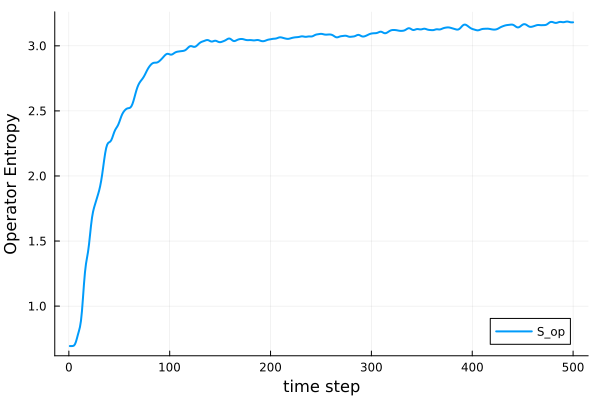

In [167]:
plot(1:steps, S_values,
     xlabel="time step",
     ylabel="Operator Entropy",
     label="S_op",
     lw=2)

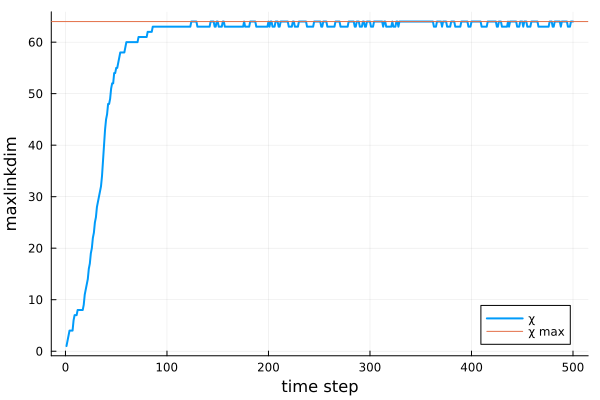

In [189]:
plot(1:steps, chi_values,
     xlabel="time step",
     ylabel="maxlinkdim",
     label="χ",
     lw=2)
hline!([2^N], label="χ max") # 2^N = dim max of the matrix

$$\chi \approx e^{S_{op}}$$

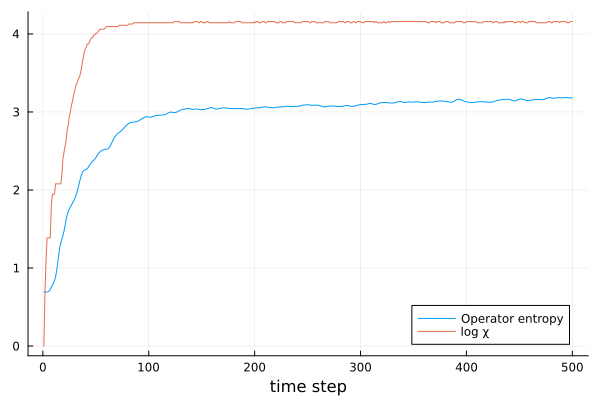

In [169]:
plot(1:steps, S_values,
     label="Operator entropy",
     xlabel="time step")

plot!(1:steps, log.(chi_values),
      label="log χ")

---

## Hydrodynamic tails

$$Trace(X_i(t)X_0)$$

With $i=0$ wich represent the qubit in the center of the chain

In [179]:
center = N÷2
X_0 = MPO(sites, "Id")
X_0[center] = op("X", sites[center])

steps = 200
steps_for_mesurement = 10

result = Vector[]
for i in 1: N÷2 # ÷2 because of symmerti
  X_i = MPO(sites, "Id")
  X_i[i] = op("X", sites[i])

  O = copy(X_i)

  trace_i = Float64[]
  for step in 1:steps
    O = evolve_operator(O, steps_for_mesurement)

    trace_temp = inner(O, X_0)
    push!(trace_i, abs(trace_temp))
  end

  push!(result, trace_i)
  println(i, "complete")
end

1complete
2complete
3complete


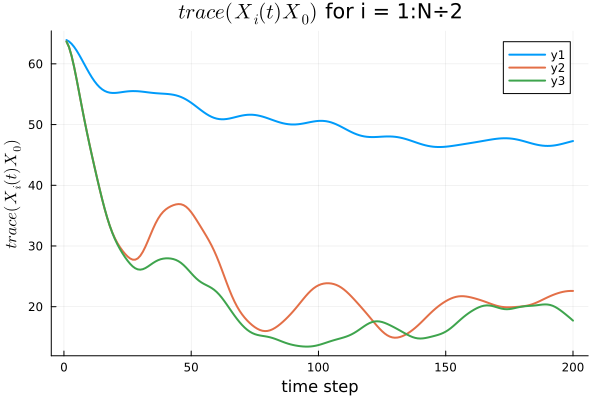

In [180]:
using LaTeXStrings

plot(1:steps, result,
     xlabel="time step",
     ylabel=L"$trace(X_i(t) X_0)$",
     label= i in 1:N÷2,
     lw=2)
title!(L"$trace(X_i(t) X_0)$ for i = 1:N÷2")

---

## References

- [Julia documentation](https://docs.julialang.org/en/v1/)
- [ITensor documentation](https://docs.itensor.org/ITensors/stable/index.html)
- https://docs.juliaplots.org/dev/tutorial/
- https://www.phys.ens.psl.eu/~jacobsen/AMP21_Dubail.pdf
- https://tensornetwork.org/mps/algorithms/timeevo/tebd.html